/Users/shasmitha_r/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


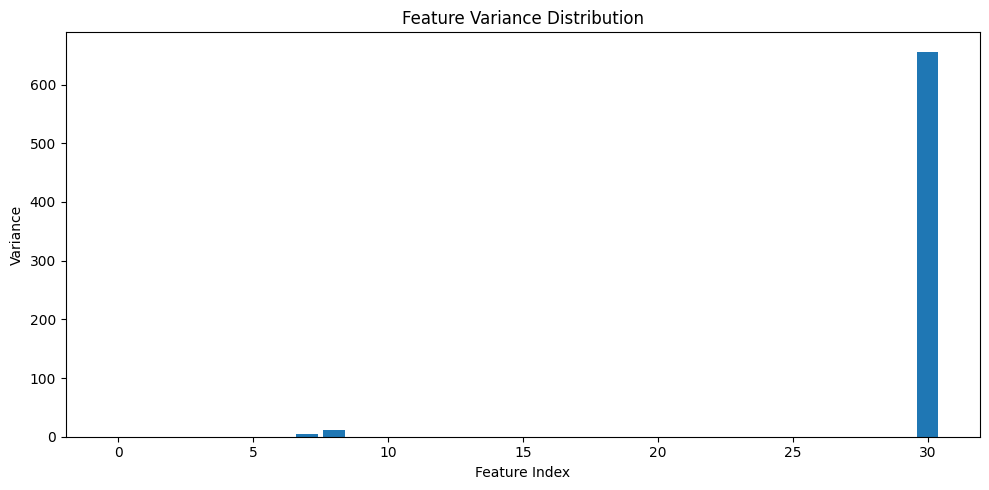

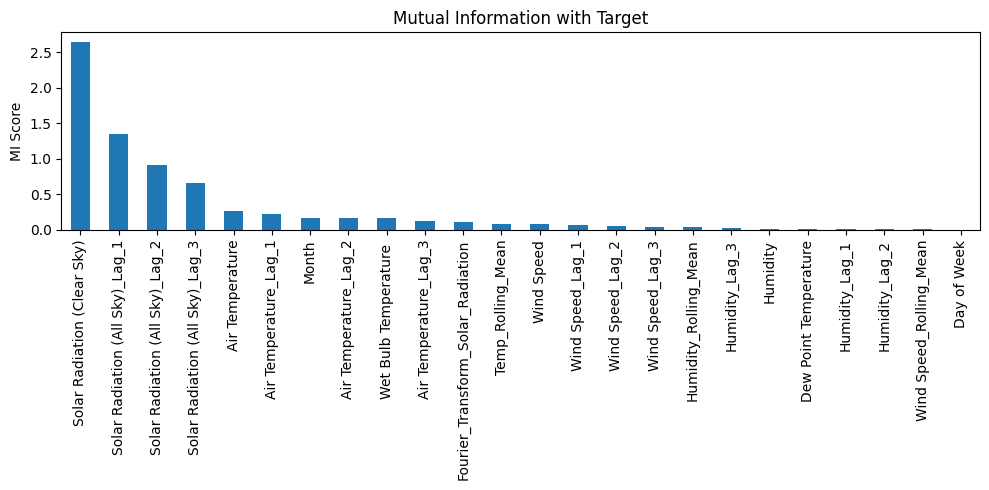

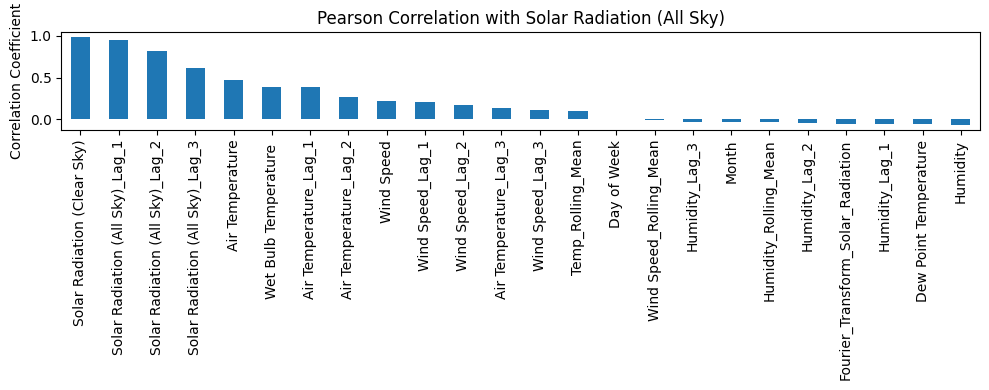

100%|===================| 19880/19930 [04:58<00:00]        

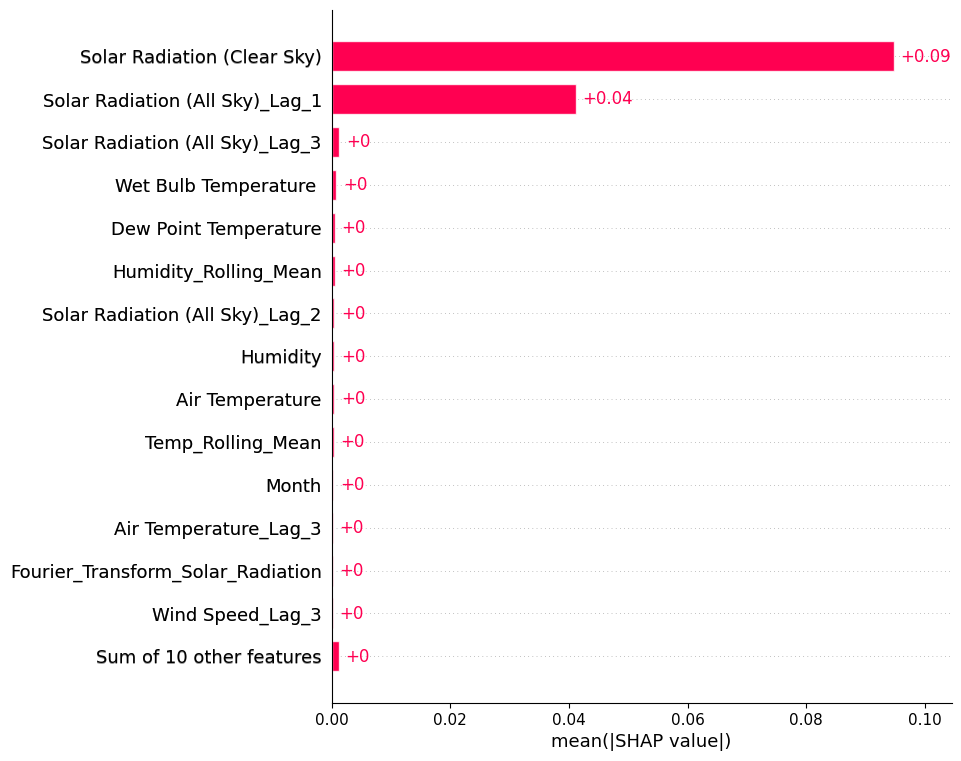

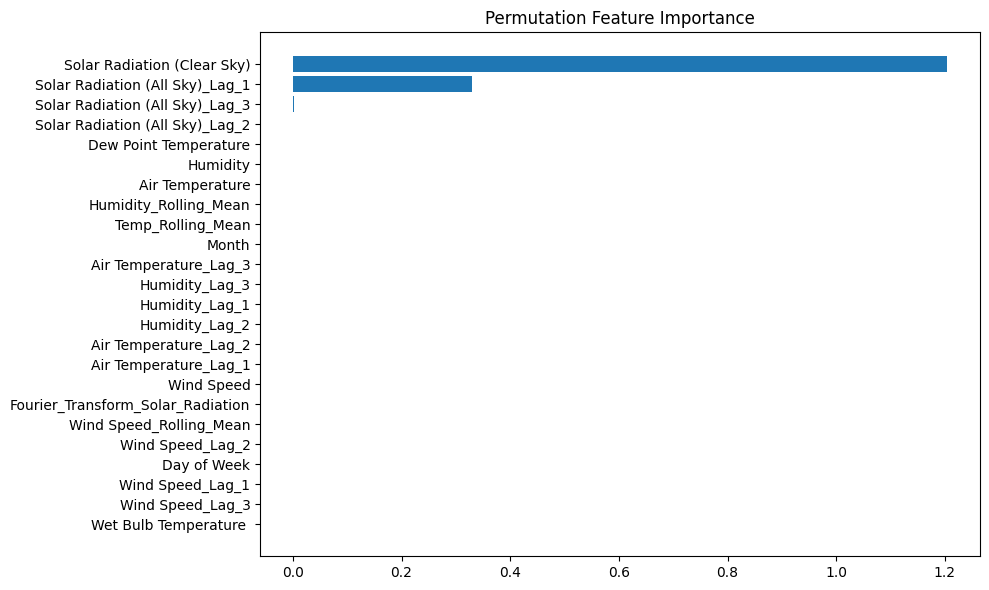

✅ Reduced dataset saved as 'reduced_dataset.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import shap

# 1. 🔄 Load dataset
df = pd.read_csv("/Users/shasmitha_r/Desktop/SAUDI/approah 1 fe datset.csv")

# 2. 🎯 Set target column
target = "Solar Radiation (All Sky)"

# 3. 🧹 Drop 'Datetime' and extract features/target
df = df.drop(columns=["Datetime"])  # Drop non-numeric time column if present
X = df.drop(columns=[target])
y = df[target]

# 4. 🧼 Keep only numeric features and drop columns with NA
X = X.select_dtypes(include=[np.number]).dropna(axis=1)

# 5. 🧾 Apply Variance Threshold
sel = VarianceThreshold(threshold=0.01)
X_var = sel.fit_transform(X)
selected_features = X.columns[sel.get_support()]
X_reduced = pd.DataFrame(X_var, columns=selected_features)

# 📊 Plot feature variances
plt.figure(figsize=(10, 5))
plt.bar(range(len(sel.variances_)), sel.variances_)
plt.title("Feature Variance Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.tight_layout()
plt.show()

# 6. 📈 Mutual Information with Target
mi_scores = mutual_info_regression(X[selected_features], y)
mi_series = pd.Series(mi_scores, index=selected_features).sort_values(ascending=False)

# 📊 Plot MI scores
plt.figure(figsize=(10, 5))
mi_series.plot(kind="bar")
plt.title("Mutual Information with Target")
plt.ylabel("MI Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 7. 🔗 Pearson Correlation with Target
corrs = X_reduced.apply(lambda col: col.corr(y, method="pearson"))
corrs.sort_values(ascending=False).plot(kind='bar', figsize=(10, 4))
plt.title(f"Pearson Correlation with {target}")
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 8. 🌲 SHAP & Permutation Importance
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔍 SHAP Feature Importance
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train)
shap.plots.bar(shap_values, max_display=15)

# 📊 Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_idx = perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.barh(X_reduced.columns[perm_idx], perm.importances_mean[perm_idx])
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 9. 💾 Save Reduced Dataset
df_reduced = X_reduced.copy()
df_reduced[target] = y
df_reduced.to_csv("reduced_dataset.csv", index=False)
print("✅ Reduced dataset saved as 'reduced_dataset.csv'")


In [2]:
print(df.columns.tolist())


['Solar Radiation (All Sky)', 'Solar Radiation (Clear Sky)', 'Air Temperature', 'Dew Point Temperature', 'Wet Bulb Temperature ', 'Humidity', 'Precipitation', 'Wind Speed', 'Day of Week', 'Month', 'Temp_Humidity_Interaction', 'Solar Radiation (All Sky)_Lag_1', 'Air Temperature_Lag_1', 'Humidity_Lag_1', 'Wind Speed_Lag_1', 'Solar Radiation (All Sky)_Lag_2', 'Air Temperature_Lag_2', 'Humidity_Lag_2', 'Wind Speed_Lag_2', 'Solar Radiation (All Sky)_Lag_3', 'Air Temperature_Lag_3', 'Humidity_Lag_3', 'Wind Speed_Lag_3', 'Temp_Rolling_Mean', 'Humidity_Rolling_Mean', 'Wind Speed_Rolling_Mean', 'Precipitation_Rolling_Mean', 'Temp_Rolling_Std', 'Humidity_Rolling_Std', 'Wind Speed_Rolling_Std', 'Precipitation_Rolling_Std', 'Fourier_Transform_Solar_Radiation']


📌 Calculating Mutual Information...
📌 Calculating Pearson Correlation...
📌 Calculating SHAP values on a sample of data...
📌 Calculating Permutation Importance...
📌 Normalizing and averaging scores...

🔝 Top 10 Important Features:

Solar Radiation (Clear Sky)        1.000000
Solar Radiation (All Sky)_Lag_1    0.479937
Solar Radiation (All Sky)_Lag_2    0.293434
Solar Radiation (All Sky)_Lag_3    0.220570
Air Temperature                    0.145502
Air Temperature_Lag_1              0.118163
Wet Bulb Temperature               0.113561
Air Temperature_Lag_2              0.082872
Wind Speed                         0.063864
Temp_Humidity_Interaction          0.061989
Name: Avg_Score, dtype: float64


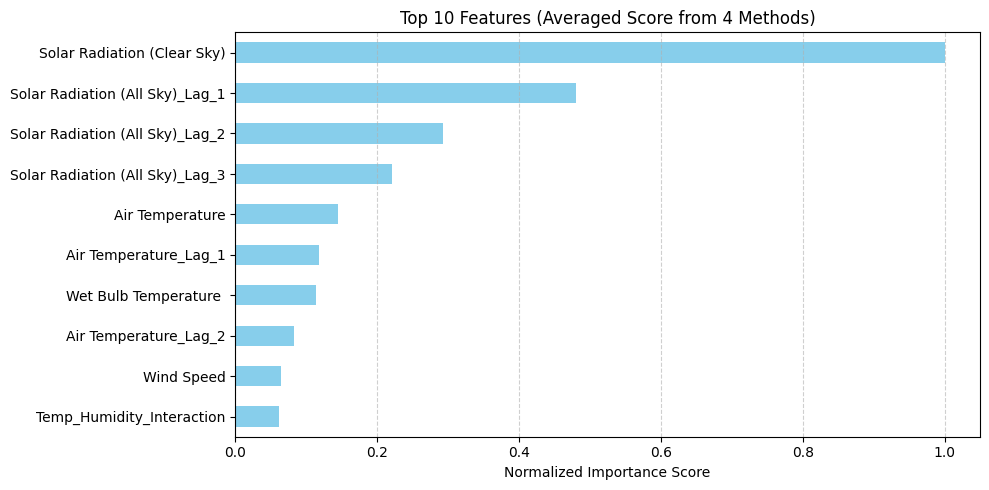


⏱️ Total Time Taken: 166.56 seconds


In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
import shap
import time
import matplotlib.pyplot as plt

# -------------------- INPUT DATA --------------------
# Ensure X and y are already defined
features = X.columns.tolist()

# -------------------- TIMER START --------------------
start = time.time()

# 1. Mutual Information
print("📌 Calculating Mutual Information...")
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features).sort_values(ascending=False)

# 2. Pearson Correlation
print("📌 Calculating Pearson Correlation...")
corr_scores = X.corrwith(y).abs().sort_values(ascending=False)

# 3. SHAP (sample-based)
print("📌 Calculating SHAP values on a sample of data...")
model = RandomForestRegressor(random_state=42).fit(X, y)
sample_X = X.sample(n=min(500, len(X)), random_state=42)  # fast sample
explainer = shap.TreeExplainer(model)
shap_values = np.abs(explainer.shap_values(sample_X)).mean(axis=0)
shap_scores = pd.Series(shap_values, index=features).sort_values(ascending=False)

# 4. Permutation Importance
print("📌 Calculating Permutation Importance...")
perm_result = permutation_importance(model, X, y, n_repeats=5, random_state=42, n_jobs=-1)
perm_scores = pd.Series(perm_result.importances_mean, index=features).sort_values(ascending=False)

# -------------------- SCORE NORMALIZATION --------------------
print("📌 Normalizing and averaging scores...")
scores_df = pd.DataFrame({
    'MI': mi_scores / mi_scores.max(),
    'Corr': corr_scores / corr_scores.max(),
    'SHAP': shap_scores / shap_scores.max(),
    'Perm': perm_scores / perm_scores.max()
})

scores_df['Avg_Score'] = scores_df.mean(axis=1)
top_features = scores_df['Avg_Score'].sort_values(ascending=False).head(10)

# -------------------- RESULTS --------------------
print("\n🔝 Top 10 Important Features:\n")
print(top_features)

# -------------------- OPTIONAL: Plot --------------------
plt.figure(figsize=(10, 5))
top_features.sort_values().plot(kind='barh', color='skyblue')
plt.title("Top 10 Features (Averaged Score from 4 Methods)")
plt.xlabel("Normalized Importance Score")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -------------------- TIME TAKEN --------------------
print(f"\n⏱️ Total Time Taken: {round(time.time() - start, 2)} seconds")
